In [ ]:
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

# Set the file path to your dataset
file_path = "/content/DDoS_dataset.csv"

# Load the dataset into a DataFrame using pandas
import pandas as pd
df = pd.read_csv(file_path)

# Display the first few rows of the dataset
df.head()


Mounted at /content/drive


,Highest Layer,Transport Layer,Source IP,Dest IP,Source Port,Dest Port,Packet Length,Packets/Time,target
0,ARP,UDP,1,192.168.1.1,0,0,60,92.8,1
1,ARP,UDP,0,192.168.1.10,0,0,42,92.9,0
2,ARP,UDP,1,192.168.1.1,0,0,60,362.8,1
3,ARP,UDP,0,192.168.1.12,0,0,42,362.8,0
4,ARP,UDP,1,192.168.1.1,0,0,60,364.3,1


In [ ]:
# Check the shape and info of the dataset
df.info()

# View summary statistics
df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 852585 entries, 0 to 852584
Data columns (total 9 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   Highest Layer    852585 non-null  object 
 1   Transport Layer  852585 non-null  object 
 2   Source IP        852585 non-null  int64  
 3   Dest IP          852585 non-null  object 
 4   Source Port      852585 non-null  int64  
 5   Dest Port        852585 non-null  int64  
 6   Packet Length    852585 non-null  int64  
 7   Packets/Time     852585 non-null  float64
 8   target           852585 non-null  int64  
dtypes: float64(1), int64(5), object(3)
memory usage: 58.5+ MB


,Source IP,Source Port,Dest Port,Packet Length,Packets/Time,target
count,852585.000000,852585.000000,852585.000000,852585.000000,852585.000000,852585.000000
mean,0.466506,48986.260599,4163.623361,770.617703,192.782676,0.466506
std,0.498877,13175.856007,8453.836606,714.423026,143.208412,0.498877
min,0.000000,0.000000,0.000000,42.000000,0.000000,0.000000
25%,0.000000,49158.000000,80.000000,60.000000,28.900000,0.000000
50%,0.000000,49158.000000,5201.000000,342.000000,217.900000,0.000000
75%,1.000000,50890.000000,5201.000000,1514.000000,281.900000,1.000000
max,1.000000,65530.000000,50890.000000,1514.000000,484.400000,1.000000


In [ ]:
# Check for missing values and remove them (if any)
df = df.dropna()


In [ ]:
# Check the columns to identify features and labels
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 852585 entries, 0 to 852584
Data columns (total 6 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Source IP      852585 non-null  int64  
 1   Source Port    852585 non-null  int64  
 2   Dest Port      852585 non-null  int64  
 3   Packet Length  852585 non-null  int64  
 4   Packets/Time   852585 non-null  float64
 5   target         852585 non-null  int64  
dtypes: float64(1), int64(5)
memory usage: 39.0 MB


In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Separate features (X) and target (y)
X = df.drop(columns=['target'])  # Features: Source IP, Source Port, Dest Port, Packet Length, Packets/Time
y = df['target']  # Target: Normal or DDoS



In [ ]:
# 2. Scale the features - Normalize the numeric data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)



In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)


#4 Display the first few rows of the scaled features and target
print(X_train[:5])  # Show the first 5 rows of scaled features
print(y_train[:5])  # Show the first 5 rows of the target (Normal/DDoS)


[[-0.8644046  -0.61409964 -0.93511243 -0.21621135  0.01303441  0.12271082
   1.0405358   0.65231768]
 [ 1.38697436 -0.61409964  1.06939013 -0.21621135  0.05143801 -0.48305
  -0.99187469 -1.29379819]
 [ 1.38697436 -0.61409964  1.06939013 -0.21621135  0.03132545 -0.48305
  -0.98627576 -1.29589304]
 [ 1.38697436 -0.61409964  1.06939013 -0.21621135  0.03845972 -0.48305
  -0.99187469 -1.29449648]
 [ 0.63651471  1.62840023  1.06939013 -0.21621135  0.5463587  -0.48305
  -0.99467416  1.94763341]]
424102    0
727694    1
776912    1
817653    1
639036    1
Name: target, dtype: int64


In [ ]:
#Step 5: Train a Simple Machine Learning Model (Random Forest)
from sklearn.ensemble import RandomForestClassifier

# Train Random Forest Classifier
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)


In [ ]:
#STEP 6-EVALUATE THE MODEL
from sklearn.metrics import accuracy_score, classification_report

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy * 100:.2f}%')

# Classification report (precision, recall, F1 score)
print("Classification Report:\n", classification_report(y_test, y_pred))


Accuracy: 100.00%
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     90970
           1       1.00      1.00      1.00     79547

    accuracy                           1.00    170517
   macro avg       1.00      1.00      1.00    170517
weighted avg       1.00      1.00      1.00    170517



In [ ]:
#STEP 7- MAKE PREDICTIONS WITH NEW DATA
# After scaling, convert back to DataFrame for easy indexing (optional but helpful)
import pandas as pd

# Convert scaled data back to DataFrame (with column names preserved)
X_train_df = pd.DataFrame(X_train, columns=df.drop(columns=['target']).columns)
X_test_df = pd.DataFrame(X_test, columns=df.drop(columns=['target']).columns)

# Example: Test prediction on first 5 rows from the test set
sample_data = X_test_df.iloc[:5]  # Take first 5 rows of the test set
predictions = model.predict(sample_data)

# Show the predictions for these 5 samples
print("Predictions for Sample Data:", predictions)


Predictions for Sample Data: [0 0 1 0 1]


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


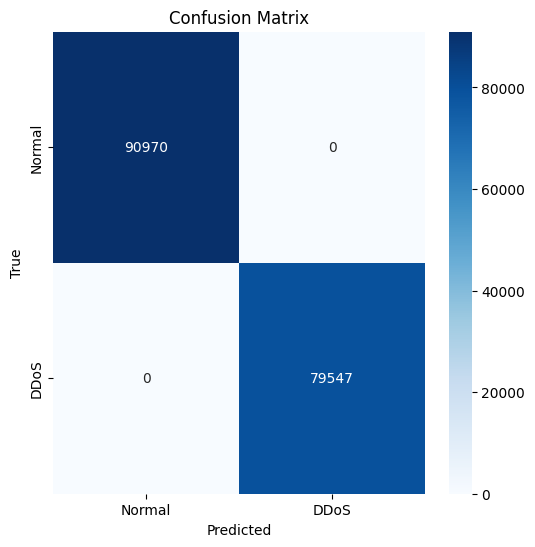

In [ ]:
#STEP 8- VISUALIZE THE RESULT
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Plot confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Normal', 'DDoS'], yticklabels=['Normal', 'DDoS'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()


In [ ]:
!pip install tensorflow


In [ ]:
# Build the Neural Network model
model_nn = Sequential()


In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Load dataset
df = pd.read_csv("DDoS_dataset.csv")

# Encode categorical columns
label_encoders = {}
for col in ["Highest Layer", "Transport Layer", "Dest IP"]:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

# Separate features and target
X = df.drop(columns=["target"])
y = df["target"]

# Normalize numerical features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split data
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)

# Define neural network model
model = keras.Sequential([
    layers.Dense(16, activation='relu', input_shape=(X_train.shape[1],)),
    layers.Dense(32, activation='relu'),
    layers.Dense(16, activation='relu'),
    layers.Dense(1, activation='sigmoid')  # Binary classification
])

# Compile model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train model
history = model.fit(X_train, y_train, epochs=10, batch_size=32, validation_data=(X_test, y_test), verbose=1)

# Evaluate the model
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {test_acc:.4f}")


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
21315/21315 ━━━━━━━━━━━━━━━━━━━━ 62s 3ms/step - accuracy: 0.9971 - loss: 0.0111 - val_accuracy: 1.0000 - val_loss: 3.1599e-09
Epoch 2/10
21315/21315 ━━━━━━━━━━━━━━━━━━━━ 91s 3ms/step - accuracy: 1.0000 - loss: 2.1828e-09 - val_accuracy: 1.0000 - val_loss: 1.2916e-09
Epoch 3/10
21315/21315 ━━━━━━━━━━━━━━━━━━━━ 74s 3ms/step - accuracy: 1.0000 - loss: 1.2514e-09 - val_accuracy: 1.0000 - val_loss: 1.1709e-09
Epoch 4/10
21315/21315 ━━━━━━━━━━━━━━━━━━━━ 80s 3ms/step - accuracy: 1.0000 - loss: 1.1550e-09 - val_accuracy: 1.0000 - val_loss: 1.0648e-09
Epoch 5/10
21315/21315 ━━━━━━━━━━━━━━━━━━━━ 81s 3ms/step - accuracy: 1.0000 - loss: 1.0337e-09 - val_accuracy: 1.0000 - val_loss: 9.7278e-10
Epoch 6/10
21315/21315 ━━━━━━━━━━━━━━━━━━━━ 81s 3ms/step - accuracy: 1.0000 - loss: 9.5947e-10 - val_accuracy: 1.0000 - val_loss: 8.9886e-10
Epoch 7/10
21315/21315 ━━━━━━━━━━━━━━━━━━━━ 83s 3ms/step - accuracy: 1.0000 - loss: 8.8859e-10 - val_accuracy: 1.0000 - val_loss: 8.5422e-10
Epoch 8/10
21315/

In [ ]:
# Evaluate the model on the test data
loss, accuracy = model_nn.evaluate(X_test, y_test)
print(f"Neural Network Accuracy: {accuracy * 100:.2f}%")

5329/5329 ━━━━━━━━━━━━━━━━━━━━ 12s 2ms/step - accuracy: 1.0000 - loss: 1.3620e-08
Neural Network Accuracy: 100.00%


In [ ]:
#LSTM MODEL
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Load dataset
df = pd.read_csv("DDoS_dataset.csv")

# Encode categorical columns
label_encoders = {}
for col in ["Highest Layer", "Transport Layer", "Dest IP"]:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

# Separate features and target
X = df.drop(columns=["target"])
y = df["target"]

# Normalize numerical features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Reshape input for LSTM (samples, timesteps, features)
X_reshaped = X_scaled.reshape(X_scaled.shape[0], 1, X_scaled.shape[1])

# Split data
X_train, X_test, y_train, y_test = train_test_split(X_reshaped, y, test_size=0.2, random_state=42, stratify=y)

# Define LSTM model
model = keras.Sequential([
    layers.LSTM(16, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])),
    layers.Dropout(0.3),  # Prevent overfitting
    layers.LSTM(8),
    layers.Dropout(0.3),
    layers.Dense(1, activation='sigmoid')  # Binary classification
])

# Compile model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train model
history = model.fit(X_train, y_train, epochs=5, batch_size=64, validation_data=(X_test, y_test), verbose=1)

# Evaluate the model
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {test_acc:.4f}")


Epoch 1/5


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


10658/10658 ━━━━━━━━━━━━━━━━━━━━ 50s 4ms/step - accuracy: 0.9909 - loss: 0.0742 - val_accuracy: 1.0000 - val_loss: 5.9368e-07
Epoch 2/5
10658/10658 ━━━━━━━━━━━━━━━━━━━━ 47s 4ms/step - accuracy: 1.0000 - loss: 1.6155e-04 - val_accuracy: 1.0000 - val_loss: 3.0693e-10
Epoch 3/5
10658/10658 ━━━━━━━━━━━━━━━━━━━━ 86s 5ms/step - accuracy: 1.0000 - loss: 7.6883e-05 - val_accuracy: 1.0000 - val_loss: 1.7183e-12
Epoch 4/5
10658/10658 ━━━━━━━━━━━━━━━━━━━━ 53s 5ms/step - accuracy: 1.0000 - loss: 9.8613e-05 - val_accuracy: 1.0000 - val_loss: 1.4773e-13
Epoch 5/5
10658/10658 ━━━━━━━━━━━━━━━━━━━━ 48s 4ms/step - accuracy: 1.0000 - loss: 6.3409e-05 - val_accuracy: 1.0000 - val_loss: 3.7988e-15
5329/5329 ━━━━━━━━━━━━━━━━━━━━ 11s 2ms/step - accuracy: 1.0000 - loss: 3.7505e-15
Test Accuracy: 1.0000


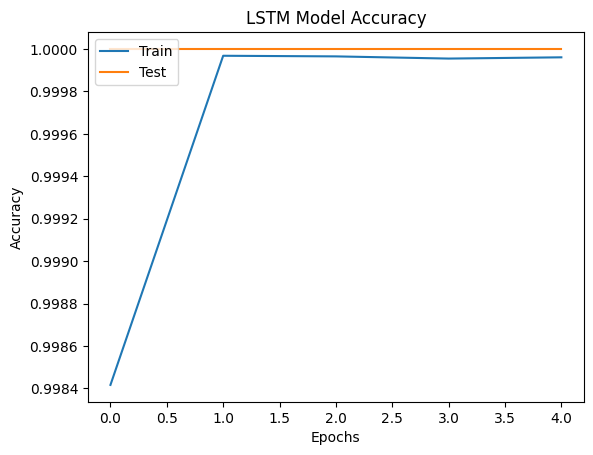

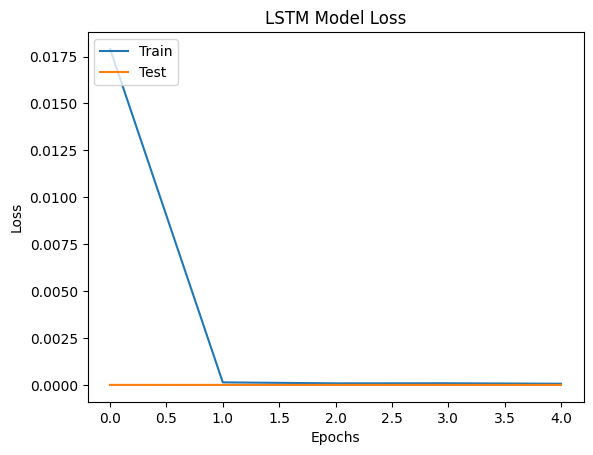

In [ ]:
import matplotlib.pyplot as plt

# Plot training & validation accuracy for LSTM model
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('LSTM Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Test'], loc='upper left')
plt.show()

# Plot training & validation loss for LSTM model
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('LSTM Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(['Train', 'Test'], loc='upper left')
plt.show()


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Train Random Forest Classifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train.reshape(X_train.shape[0], X_train.shape[2]), y_train)  # Flatten LSTM input for RF
y_rf_pred = rf_model.predict(X_test.reshape(X_test.shape[0], X_test.shape[2]))
rf_acc = accuracy_score(y_test, y_rf_pred)

# Evaluate LSTM Model
test_loss_lstm, lstm_acc = model.evaluate(X_test, y_test)

# Train Neural Network Model (if not already trained)
nn_model = keras.Sequential([
    layers.Dense(16, activation='relu', input_shape=(X_train.shape[2],)),
    layers.Dense(32, activation='relu'),
    layers.Dense(16, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])
nn_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
nn_model.fit(X_train.reshape(X_train.shape[0], X_train.shape[2]), y_train, epochs=5, batch_size=64, verbose=0)

# Evaluate Neural Network Model
test_loss_nn, nn_acc = nn_model.evaluate(X_test.reshape(X_test.shape[0], X_test.shape[2]), y_test)

# Random Classifier
y_random_pred = np.random.randint(0, 2, size=y_test.shape)
random_acc = accuracy_score(y_test, y_random_pred)


5329/5329 ━━━━━━━━━━━━━━━━━━━━ 12s 2ms/step - accuracy: 1.0000 - loss: 3.7505e-15


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


5329/5329 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step - accuracy: 1.0000 - loss: 1.4600e-09


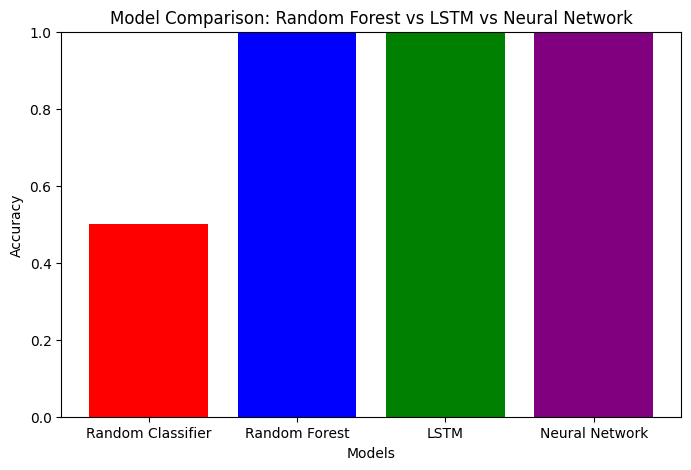

In [ ]:
# Model Names & Accuracies
models = ["Random Classifier", "Random Forest", "LSTM", "Neural Network"]
accuracies = [random_acc, rf_acc, lstm_acc, nn_acc]

# Plot Accuracy Comparison
plt.figure(figsize=(8,5))
plt.bar(models, accuracies, color=['red', 'blue', 'green', 'purple'])
plt.ylim(0, 1)  # Accuracy range (0 to 100%)
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.title("Model Comparison: Random Forest vs LSTM vs Neural Network")
plt.show()
